<a href="https://colab.research.google.com/github/Piyush-Sharma-1/SI_Crystal_Generative_Model/blob/main/w_kl%26w_agg%3D0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ase -q
!pip install torch-geometric -q

[v4i3] using source at: /kaggle/input/datasets/phantomygyj/atomic-recipes/atomic-recipes-code/atomic-recipes-main
[v4i3] confirmed EquivariantDecoder present
device: cuda
ep  1 | kl_w 0.0001 | kl 868.4 | agg 327.4 | SCORE 1.666 | total 34.49
ep  2 | kl_w 0.0051 | kl 786.3 | agg 4.858 | SCORE 1.036 | total 5.528
ep  3 | kl_w 0.0101 | kl 441.5 | agg 4.376 | SCORE 1.025 | total 5.917
ep  4 | kl_w 0.0151 | kl 326.5 | agg 6.368 | SCORE 1.058 | total 6.62
ep  5 | kl_w 0.0201 | kl 258 | agg 6.807 | SCORE 0.9836 | total 6.845
ep  6 | kl_w 0.0251 | kl 216 | agg 5.835 | SCORE 1.004 | total 7.005
ep  7 | kl_w 0.0301 | kl 184.2 | agg 6.858 | SCORE 0.9851 | total 7.211
ep  8 | kl_w 0.0351 | kl 160.8 | agg 7.659 | SCORE 0.986 | total 7.391
ep  9 | kl_w 0.0401 | kl 144 | agg 9.41 | SCORE 0.9825 | total 7.692
ep 10 | kl_w 0.0451 | kl 129.7 | agg 10.59 | SCORE 0.9718 | total 7.874
ep 11 | kl_w 0.0501 | kl 119.1 | agg 10.51 | SCORE 0.9819 | total 7.994
ep 12 | kl_w 0.0550 | kl 108 | agg 8.572 | SCORE 0.

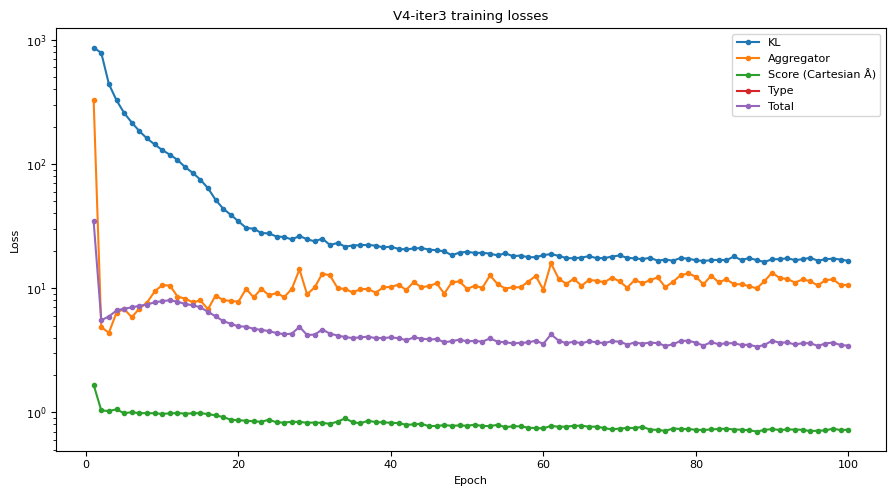

In [ ]:
#training script:

import sys, os, json, time, glob, itertools, importlib
from pathlib import Path

V4_ROOT = "/kaggle/input/datasets/phantomygyj/atomic-recipes/atomic-recipes-code/atomic-recipes-main"
assert Path(V4_ROOT).exists(), f"V4-iter3 not found at {V4_ROOT} — attach dataset"
print("[v4i3] using source at:", V4_ROOT)

for m in list(sys.modules):
    if m.startswith("atomic_recipes"):
        del sys.modules[m]
sys.path.insert(0, str(Path(V4_ROOT) / "src"))

import numpy as np, torch, pandas as pd
import torch.nn as nn, torch.nn.functional as F
from ase import io as ase_io, Atoms
import atomic_recipes.genml.vae as vae
importlib.reload(vae)
assert hasattr(vae, "EquivariantDecoder"), "Wrong vae (no EquivariantDecoder)"
print("[v4i3] confirmed EquivariantDecoder present")

from atomic_recipes.data.material import Material, MaterialsDataset
from atomic_recipes.data.graph import MaterialGraph, _niggli_to_reduced
from atomic_recipes.genml.vae import (
    GaussianPosteriorEncoder, Aggregator, LangevinDynamics,
    LossKLDivergenceGaussianPosterior, LossAggregator,
    EquivariantDecoder,
)
from atomic_recipes.regression.mpgnn import SimpleMessagePassingGNN
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.data import Batch
import matplotlib.pyplot as plt

POSCAR_500 = "/kaggle/input/datasets/phantomygyj/poscar-500"
CACHE_DIR  = Path("/kaggle/working/graph_cache_v4i3")
GEN_DIR    = "/kaggle/working/Generated_V4i3"
REF_PATH   = "/kaggle/input/datasets/phantomygyj/poscars/POSCARS25084/POSCAR_00001"
EPOCHS, BATCH, LR, HIDDEN, LATENT, N_LAYERS = 100, 16, 1e-3, 64, 32, 3
NOISE = {"sigma_start": 0.04, "sigma_end": 3}
W = {"kl": 1.0, "aggregator": 0.10, "score": 1.0, "type": 1.0}
N_SIGMAS, INNER_STEPS, EPSILON = 10, 100, 1e-5
CUTOFF, FLOOR, WIN = 6.0, 2.0, (2.0, 2.6)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
if not (CACHE_DIR / "manifest.json").exists():
    print("[cache] building fresh clean graphs (iter3 graph.py in effect)")
    files = sorted(p for p in Path(POSCAR_500).rglob("POSCAR*") if p.is_file())
    assert files
    mats = [Material(direct_positions=torch.tensor(s.get_scaled_positions()).float(),
                     atom_numbers=torch.tensor(s.numbers),
                     lattice_vectors=torch.tensor(s.get_cell().array).float())
            for s in (ase_io.read(f, format="vasp") for f in files)]
    mds = MaterialsDataset(mats); atom_types = mds.get_atom_types(); node_dim = len(atom_types)
    graph_ds = MaterialGraph(mds, cutoff=CUTOFF, use_niggli=True, noise_params=None)
    manifest = []
    for i in range(len(graph_ds)):
        torch.save(graph_ds[i], CACHE_DIR / f"graph_{i:05d}.pt"); manifest.append(f"graph_{i:05d}.pt")
    json.dump({"files": manifest, "node_dim": node_dim,
               "atom_types": {str(k): v for k, v in atom_types.items()}},
              open(CACHE_DIR/"manifest.json","w"))
meta = json.load(open(CACHE_DIR/"manifest.json"))
node_dim = meta["node_dim"]; atom_types = {int(k): v for k, v in meta["atom_types"].items()}
num_classes = node_dim

# ----- DATASET: clean + noisy pairs (CDVAE standard) -----
class NoisyOnTheFlyDataset(torch.utils.data.Dataset):
    def __init__(self, d, noise):
        self.d = Path(d); self.noise = noise
        self.f = json.load(open(self.d / "manifest.json"))["files"]

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        clean = torch.load(self.d / self.f[i], weights_only=False).clone()

        # --- build noisy copy ---
        noisy = clean.clone()
        lat3 = _niggli_to_reduced(clean.lattice_vectors)
        lo, hi = np.log(self.noise["sigma_start"]), np.log(self.noise["sigma_end"])
        sigma = torch.exp(torch.empty(1).uniform_(lo, hi))

        cart_noise = torch.randn_like(clean.pos) * sigma
        inv_lat3 = torch.linalg.inv(lat3).to(cart_noise.dtype)
        frac_noise = cart_noise @ inv_lat3
        noisy_pos = clean.pos + frac_noise
        noisy_pos = noisy_pos - noisy_pos.floor()

        row, col = clean.edge_index
        dfrac = noisy_pos[row] - noisy_pos[col]; dfrac = dfrac - dfrac.round()
        dcart = dfrac @ lat3
        noisy.pos = noisy_pos
        noisy.edge_attr = dcart.norm(dim=-1, keepdim=True)
        noisy.difference_pos = -cart_noise
        noisy.sigma = sigma

        return clean, noisy

ds = NoisyOnTheFlyDataset(CACHE_DIR, NOISE)

# Collate function to handle (clean, noisy) pairs
def collate_clean_noisy(samples):
    cleans, noisys = zip(*samples)
    return Batch.from_data_list(list(cleans)), Batch.from_data_list(list(noisys))

loader = GeoDataLoader(ds, batch_size=BATCH, shuffle=True, collate_fn=collate_clean_noisy)

enc_gnn = SimpleMessagePassingGNN(hidden_dim=HIDDEN, node_feature_dim=node_dim,
                                  update_edges=True, update_nodes=True)
encoder = GaussianPosteriorEncoder(gnn=enc_gnn, hidden_dim=HIDDEN, latent_dim=LATENT,
                                   node_feature_dim=node_dim).to(device)
aggregator = Aggregator(latent_dim=LATENT, node_feature_dim=node_dim).to(device)
score_dec = EquivariantDecoder(
    node_dim=node_dim, edge_dim=1, hidden_dim=HIDDEN, latent_dim=LATENT,
    n_layers=N_LAYERS, num_classes=num_classes,
).to(device)
kl_loss = LossKLDivergenceGaussianPosterior(); agg_loss = LossAggregator(weights=None)
params = list(encoder.parameters())+list(aggregator.parameters())+list(score_dec.parameters())
opt = torch.optim.Adam(params, lr=LR)

# Explicitly set models to training mode
encoder.train()
aggregator.train()
score_dec.train()
# --- Updated Training Loop with Stability Improvements ---
hist = {"kl": [], "aggregator": [], "score": [], "type": [], "total": []}
KL_WEIGHT_INIT = 1e-4  # Start small to prevent KL-dominance
KL_WEIGHT_FINAL = 0.1
WARMUP_EPOCHS = 20

for ep in range(EPOCHS):
    # Dynamic KL weight
    kl_weight = min(KL_WEIGHT_FINAL, KL_WEIGHT_INIT + (ep / WARMUP_EPOCHS) * (KL_WEIGHT_FINAL - KL_WEIGHT_INIT))

    a = {k: 0.0 for k in hist}; nb = 0
    for batch_idx, (clean_batch, noisy_batch) in enumerate(loader):
        clean_batch, noisy_batch = clean_batch.to(device), noisy_batch.to(device)
        opt.zero_grad()

        z, mu, std = encoder(clean_batch)
        comp, lat, natoms = aggregator(z)

        l_kl = kl_loss(mu, std)
        l_ag = agg_loss(comp, lat, natoms, node_features=clean_batch.x.float(),
                        target_lattice=clean_batch.lattice_vectors,
                        target_num_atoms=clean_batch.num_atoms.view(-1,1), batch=clean_batch.batch)

        scores, elem_logits = score_dec(noisy_batch, z)

        target_types = noisy_batch.x.argmax(dim=1)
        _sigma = noisy_batch.sigma[noisy_batch.batch].view(-1, 1)
        l_score = F.mse_loss(scores, noisy_batch.difference_pos / _sigma)
        l_type  = F.cross_entropy(elem_logits, target_types)

        # Combined loss with dynamic KL weight
        total = (kl_weight * l_kl + W["aggregator"] * l_ag
                 + W["score"] * l_score + W["type"] * l_type)

        total.backward()

        # Gradient Clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)

        opt.step()

        a["kl"]+=float(l_kl.detach()); a["aggregator"]+=float(l_ag.detach())
        a["score"]+=float(l_score.detach()); a["type"]+=float(l_type.detach())
        a["total"]+=float(total.detach()); nb+=1

    for k in hist: hist[k].append(a[k]/nb)
    print(f"ep {ep+1:2d} | kl_w {kl_weight:.4f} | kl {hist['kl'][-1]:.4g} | agg {hist['aggregator'][-1]:.4g} "
          f"| SCORE {hist['score'][-1]:.4g} | total {hist['total'][-1]:.4g}")





plt.figure(figsize=(9,5))
for k,lab in [("kl","KL"),("aggregator","Aggregator"),
              ("score","Score (Cartesian Å)"),("type","Type"),("total","Total")]:
    plt.plot(range(1,EPOCHS+1), hist[k], marker="o", ms=3, label=lab)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.yscale("log")
plt.title("V4-iter3 training losses"); plt.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/v4i3_losses.png", dpi=150); plt.show()

In [ ]:
from atomic_recipes.descriptors.ace import ACELayer

os.makedirs(GEN_DIR, exist_ok=True)

ref_structure = ase_io.read(REF_PATH, format="vasp")
ref_mat = Material(
    direct_positions=torch.tensor(ref_structure.get_scaled_positions()).float(),
    atom_numbers=torch.tensor(ref_structure.numbers),
    lattice_vectors=torch.tensor(ref_structure.get_cell().array).float()
)
mds_ref = MaterialsDataset([ref_mat])
graph_ref = MaterialGraph(mds_ref, cutoff=CUTOFF, use_niggli=True, noise_params=None)
template = graph_ref[0]
if template.lattice_vectors.dim() == 1:
    template.lattice_vectors = template.lattice_vectors.unsqueeze(0)

inv = {int(v): int(k) for k, v in atom_types.items()}

lat3_t = _niggli_to_reduced(template.lattice_vectors).to(device)
lat3 = lat3_t.cpu().numpy()
inv_lat3_t = torch.linalg.inv(lat3_t)

# --- sampling-only changes, no retraining needed ---
N_SIGMAS_GEN  = 50
POLISH_STEPS  = 400
N_GEN=100
# ----------------------------------------------------

sigmas = torch.tensor(np.geomspace(NOISE["sigma_end"], NOISE["sigma_start"], N_SIGMAS_GEN),
                      dtype=torch.float32, device=device)
print("[v4i3] sigmas Å (high->low):", sigmas.cpu().numpy().round(4))

def update_edge_attr(g, lat3_t):
    row, col = g.edge_index
    dfrac = g.pos[row] - g.pos[col]; dfrac = dfrac - dfrac.round()
    g.edge_attr = (dfrac @ lat3_t).norm(dim=-1, keepdim=True)
    return g

def min_and_nn_distance(frac, cell):
    frac = torch.as_tensor(frac, dtype=torch.float64)
    cell = torch.as_tensor(cell, dtype=torch.float64)
    shifts = torch.tensor(list(itertools.product([-1,0,1], repeat=3)), dtype=torch.float64)
    N = frac.shape[0]
    d = (frac[:,None,:] - frac[None,:,:])[:,:,None,:] + shifts[None,None,:,:]
    dist = (d @ cell).norm(dim=-1)
    eye = torch.eye(N, dtype=torch.bool); zero = (shifts.abs().sum(1) == 0)
    dist[eye[:,:,None] & zero[None,None,:]] = float("inf")
    pm = dist.amin(dim=2)
    return pm.min().item(), pm.min(dim=1).values.median().item()

encoder.eval(); aggregator.eval(); score_dec.eval()
t_gen = time.time(); gen_paths = []; rows = []; torch.manual_seed(0)
sigma_L = sigmas[-1]

for k in range(N_GEN):
    g = template.clone().to(device)
    g.pos = torch.rand_like(g.pos)
    g.batch = torch.zeros(g.pos.shape[0], dtype=torch.long, device=device)
    g.num_graphs = 1
    if g.lattice_vectors.dim() == 1:
        g.lattice_vectors = g.lattice_vectors.unsqueeze(0)

    z = torch.randn(1, LATENT, device=device)
    with torch.no_grad():
        for sigma_j in sigmas:
            g.sigma = sigma_j.view(1).to(device)
            alpha_j = (EPSILON * (sigma_j**2) / (sigma_L**2)).item()
            for _ in range(INNER_STEPS):
                g = update_edge_attr(g, lat3_t)
                scores, _ = score_dec(g, z)
                true_scores = scores / sigma_j
                noise = torch.randn_like(g.pos)
                cart_update = alpha_j * true_scores + (2 * alpha_j)**0.5 * noise
                frac_update = cart_update @ inv_lat3_t
                g.pos = g.pos + frac_update
                g.pos = torch.remainder(g.pos, 1.0)

        # --- polishing phase: same sigma_L, noise OFF, just keep following the score ---
        g.sigma = sigma_L.view(1).to(device)
        alpha_L = EPSILON  # alpha_j at sigma_j == sigma_L reduces to EPSILON
        for _ in range(POLISH_STEPS):
            g = update_edge_attr(g, lat3_t)
            scores, _ = score_dec(g, z)
            true_scores = scores / sigma_L
            cart_update = alpha_L * true_scores          # no stochastic noise term here
            frac_update = cart_update @ inv_lat3_t
            g.pos = g.pos + frac_update
            g.pos = torch.remainder(g.pos, 1.0)

    frac = g.pos.cpu().numpy()
    znums = [inv[int(c)] for c in template.x.argmax(1).tolist()]

    atoms = Atoms(numbers=znums, scaled_positions=frac, cell=lat3, pbc=True)
    p = f"{GEN_DIR}/POSCAR_gen_{k:03d}"
    ase_io.write(p, atoms, format="vasp"); gen_paths.append(p)
    md, nn = min_and_nn_distance(frac, lat3)
    FLOOR = 2.2
    rows.append({"structure": k, "min_dist_A": round(md,3), "nn_median_A": round(nn,3),
                 "passes_floor": md >= FLOOR, "nn_in_window": WIN[0] <= nn <= WIN[1]})

print(f"[gen] {len(gen_paths)} structures in {time.time()-t_gen:.1f}s -> {GEN_DIR}")
df = pd.DataFrame(rows)
print(f"\nBond-length filter (floor={FLOOR} A, Si window={WIN[0]}-{WIN[1]} A)")
print(df.to_string(index=False))
print(f"\nPassed overlap floor: {int(df['passes_floor'].sum())}/20  |  "
      f"NN in Si window: {int(df['nn_in_window'].sum())}/20")
df.to_csv("/kaggle/working/v4i3_bondlength_filter.csv", index=False)

[v4i3] sigmas Å (high->low): [3.     2.747  2.5153 2.3031 2.1089 1.931  1.7682 1.619  1.4825 1.3574
 1.243  1.1381 1.0421 0.9542 0.8738 0.8001 0.7326 0.6708 0.6142 0.5624
 0.515  0.4715 0.4318 0.3954 0.362  0.3315 0.3035 0.2779 0.2545 0.233
 0.2134 0.1954 0.1789 0.1638 0.15   0.1373 0.1258 0.1151 0.1054 0.0965
 0.0884 0.0809 0.0741 0.0679 0.0621 0.0569 0.0521 0.0477 0.0437 0.04  ]
[gen] 20 structures in 339.7s -> /kaggle/working/Generated_V4i3

Bond-length filter (floor=2.2 A, Si window=2.0-2.6 A)
 structure  min_dist_A  nn_median_A  passes_floor  nn_in_window
         0       2.156        2.342         False          True
         1       2.248        2.355          True          True
         2       2.159        2.292         False          True
         3       2.319        2.389          True          True
         4       2.172        2.310         False          True
         5       2.325        2.381          True          True
         6       2.204        2.332          True

Loaded 20 raw structures for analysis.

Similarity to Simple Cubic (Raw):     [0.865 0.869 0.864 0.87  0.864 0.869 0.869 0.867 0.862 0.87  0.866 0.863
 0.87  0.868 0.871 0.868 0.869 0.867 0.868 0.87 ]


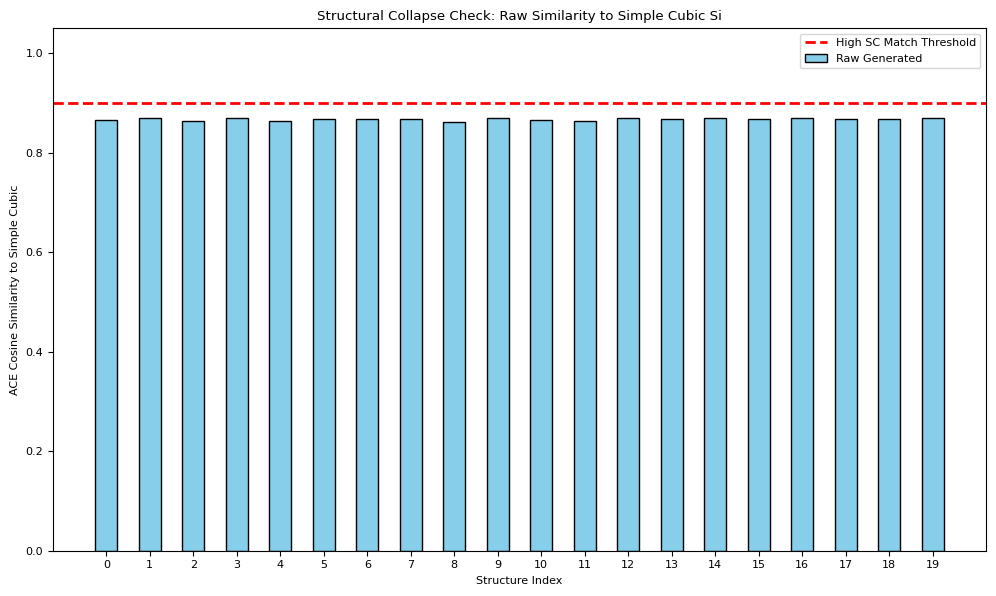

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from ase import io as ase_io, Atoms
from ase.build import make_supercell
from atomic_recipes.descriptors.ace import ACELayer
from atomic_recipes.data.material import Material, MaterialsDataset

# 1. Setup Device and Directories
device = "cuda" if torch.cuda.is_available() else "cpu"
GEN_DIR = "/kaggle/working/Generated_V4i3"

# 2. Define the ACE Descriptor Function (Extracted from your notebook)
ace = ACELayer(n_limits=[2, 2, 2], l_limits=[2, 2, 2]).to(device)

def ace_fp(atoms_list):
    """Calculates the Atomic Cluster Expansion fingerprint for a list of ASE Atoms."""
    mats = [Material(direct_positions=torch.tensor(a.get_scaled_positions()).float(),
                     atom_numbers=torch.tensor(a.numbers),
                     lattice_vectors=torch.tensor(a.get_cell().array).float())
            for a in atoms_list]
    with torch.no_grad():
        B, _, _ = ace(MaterialsDataset(mats))
    return B.mean(dim=1).cpu().numpy()

# 3. Create the Simple Cubic (SC) Reference
a_sc = 2.715
sc_prim = Atoms('Si', scaled_positions=[[0.0, 0.0, 0.0]], cell=[a_sc, a_sc, a_sc], pbc=True)
sc_ref_atoms = make_supercell(sc_prim, 2 * np.eye(3))

# 4. Load ONLY the Unrelaxed (Raw) structures
unrelaxed_atoms = []
valid_indices = []

for i in range(20):
    unrelax_path = f"{GEN_DIR}/POSCAR_gen_{i:03d}"
    if os.path.exists(unrelax_path):
        unrelaxed_atoms.append(ase_io.read(unrelax_path, format="vasp"))
        valid_indices.append(i)

print(f"Loaded {len(valid_indices)} raw structures for analysis.")

# 5. Calculate ACE Fingerprints
all_atoms = [sc_ref_atoms] + unrelaxed_atoms
fps_all = ace_fp(all_atoms)

# 6. Extract the Simple Cubic reference fingerprint and normalize it
fp_sc = fps_all[0]
rf_sc = fp_sc / (np.linalg.norm(fp_sc) + 1e-12)

# Slice out the unrelaxed arrays
fps_unrelaxed = fps_all[1:]

# 7. Calculate Cosine Similarities
sims_unrelaxed = np.array([float(np.dot(rf_sc, f/(np.linalg.norm(f)+1e-12))) for f in fps_unrelaxed])

print("\nSimilarity to Simple Cubic (Raw):    ", sims_unrelaxed.round(3))

# 8. Plot the Graph (Raw Only)
plt.figure(figsize=(10, 6))
x = np.arange(len(valid_indices))

plt.bar(x, sims_unrelaxed, width=0.5, label='Raw Generated', color='skyblue', edgecolor='black')

plt.xlabel("Structure Index")
plt.ylabel("ACE Cosine Similarity to Simple Cubic")
plt.title("Structural Collapse Check: Raw Similarity to Simple Cubic Si")
plt.xticks(x, valid_indices)
plt.ylim(0, 1.05)
plt.axhline(y=0.90, color='red', linestyle='--', linewidth=2, label="High SC Match Threshold")

plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/sc_similarity_raw_only.png", dpi=150)
plt.show()

In [ ]:
!pip install mace-torch -q

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Calculating Reference Energies...
  -> Simple Cubic Si Energy: -5.180 eV/atom
  -> Diamond Si Energy:      -5.371 eV/atom

Relaxing generated structures (this fixes the overlapping atoms)...

Successfully relaxed 20/20 structures.


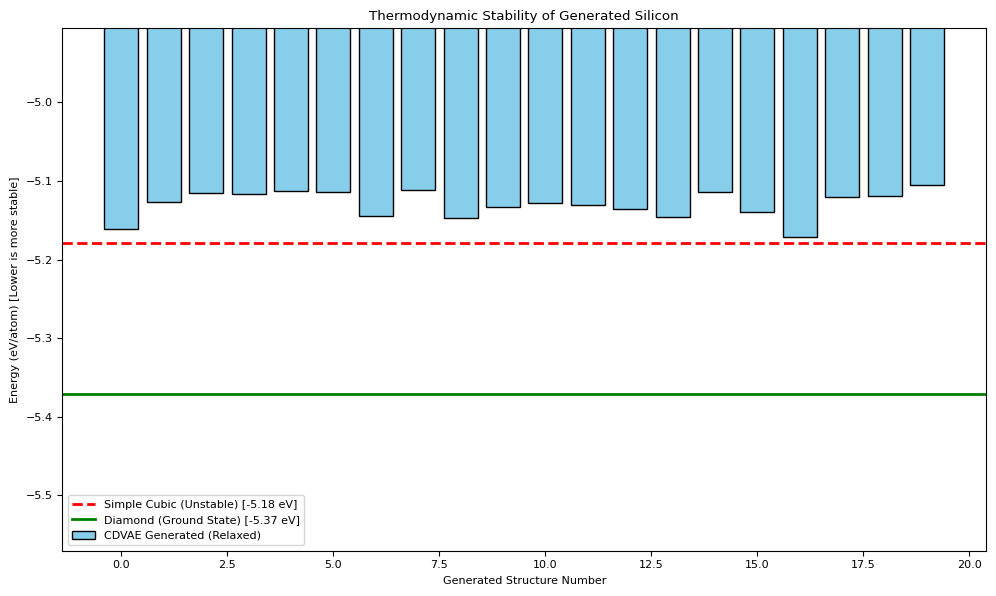

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from ase import io as ase_io, Atoms
from ase.optimize import FIRE
from ase.filters import FrechetCellFilter
from mace.calculators import mace_mp

# 1. Initialize the MACE Universal Potential
# (Downloads the pre-trained 'small' model automatically ~40MB)
macemp = mace_mp(model="small", device=device, default_dtype="float32")

# 2. Define and Relax References (Simple Cubic & Diamond)
print("Calculating Reference Energies...")

# Simple Cubic Si Reference (Density matched to Diamond)
sc_si = Atoms('Si', scaled_positions=[[0.0, 0.0, 0.0]], cell=[2.715, 2.715, 2.715], pbc=True)
sc_si.calc = macemp
sc_filter = FrechetCellFilter(sc_si)
FIRE(sc_filter, logfile=None).run(fmax=0.05) # fmax is max force in eV/Å
sc_energy = sc_si.get_potential_energy() / len(sc_si)
print(f"  -> Simple Cubic Si Energy: {sc_energy:.3f} eV/atom")

# Diamond Si Reference (True Ground State)
diamond_si = Atoms('Si8', scaled_positions=[
    [0, 0, 0], [0.25, 0.25, 0.25], [0, 0.5, 0.5], [0.25, 0.75, 0.75],
    [0.5, 0, 0.5], [0.75, 0.25, 0.75], [0.5, 0.5, 0], [0.75, 0.75, 0.25]
], cell=[5.431, 5.431, 5.431], pbc=True)
diamond_si.calc = macemp
dia_filter = FrechetCellFilter(diamond_si)
FIRE(dia_filter, logfile=None).run(fmax=0.05)
dia_energy = diamond_si.get_potential_energy() / len(diamond_si)
print(f"  -> Diamond Si Energy:      {dia_energy:.3f} eV/atom")

# 3. Relax the Generated Structures
RELAX_DIR = "/kaggle/working/Generated_Relaxed"
os.makedirs(RELAX_DIR, exist_ok=True)

relaxed_energies = []
valid_indices = []

print("\nRelaxing generated structures (this fixes the overlapping atoms)...")
for i, p in enumerate(gen_paths):
    try:
        atoms = ase_io.read(p, format="vasp")
        atoms.calc = macemp

        # FrechetCellFilter allows the cell shape/volume to relax alongside atomic positions
        cell_filter = FrechetCellFilter(atoms)

        # FIRE optimizer gently resolves overlaps
        opt = FIRE(cell_filter, logfile=None)
        # Cap at 300 steps so we don't get stuck on completely broken structures
        opt.run(fmax=0.05, steps=300)

        energy_per_atom = atoms.get_potential_energy() / len(atoms)
        relaxed_energies.append(energy_per_atom)
        valid_indices.append(i)

        # Save relaxed structure
        relax_path = f"{RELAX_DIR}/POSCAR_relaxed_{i:03d}"
        ase_io.write(relax_path, atoms, format="vasp")

    except Exception as e:
        print(f"  -> Structure {i:02d} failed to relax: {e}")

print(f"\nSuccessfully relaxed {len(relaxed_energies)}/20 structures.")

# 4. Energy Comparison Plot
if relaxed_energies:
    plt.figure(figsize=(10, 6))

    # Plot generated structures
    plt.bar(valid_indices, relaxed_energies, color='skyblue', edgecolor='black', label="CDVAE Generated (Relaxed)")

    # Add reference lines
    plt.axhline(y=sc_energy, color='red', linestyle='--', linewidth=2,
                label=f"Simple Cubic (Unstable) [{sc_energy:.2f} eV]")
    plt.axhline(y=dia_energy, color='green', linestyle='-', linewidth=2,
                label=f"Diamond (Ground State) [{dia_energy:.2f} eV]")

    plt.xlabel("Generated Structure Number")
    plt.ylabel("Energy (eV/atom) [Lower is more stable]")
    plt.title("Thermodynamic Stability of Generated Silicon")

    # Adjust Y-axis limits dynamically based on the data
    min_e = min(dia_energy, min(relaxed_energies)) - 0.2
    max_e = max(sc_energy, max(relaxed_energies)) + 0.2
    plt.ylim(min_e, max_e)

    plt.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/energy_comparison.png", dpi=150)
    plt.show()

In [ ]:
import os
import torch
import itertools
import pandas as pd
from ase import io as ase_io

# Define your thresholds (matching your generation script)
FLOOR = 2.0
WIN = [2.0, 2.6]
RELAX_DIR = "/kaggle/working/Generated_Relaxed"

# The distance calculator function
def min_and_nn_distance(frac, cell):
    frac = torch.as_tensor(frac, dtype=torch.float64)
    cell = torch.as_tensor(cell, dtype=torch.float64)
    shifts = torch.tensor(list(itertools.product([-1,0,1], repeat=3)), dtype=torch.float64)
    N = frac.shape[0]
    d = (frac[:,None,:] - frac[None,:,:])[:,:,None,:] + shifts[None,None,:,:]
    dist = (d @ cell).norm(dim=-1)
    eye = torch.eye(N, dtype=torch.bool); zero = (shifts.abs().sum(1) == 0)
    dist[eye[:,:,None] & zero[None,None,:]] = float("inf")
    pm = dist.amin(dim=2)
    return pm.min().item(), pm.min(dim=1).values.median().item()

rows = []
valid_count = 0

print("Analyzing Relaxed Structures...")

for k in range(20):
    p = f"{RELAX_DIR}/POSCAR_relaxed_{k:03d}"

    # Only process if the relaxation actually succeeded and saved a file
    if os.path.exists(p):
        atoms = ase_io.read(p, format="vasp")

        # Extract the NEW relaxed fractional coordinates AND the NEW relaxed lattice cell
        frac = atoms.get_scaled_positions()
        cell = atoms.get_cell().array

        # Calculate distances
        md, nn = min_and_nn_distance(frac, cell)

        rows.append({
            "structure": k,
            "min_dist_A": round(md, 3),
            "nn_median_A": round(nn, 3),
            "passes_floor": md >= FLOOR,
            "nn_in_window": WIN[0] <= nn <= WIN[1]
        })
        valid_count += 1

# Display the results
if valid_count > 0:
    df_relax = pd.DataFrame(rows)
    print(f"\nRelaxed Bond-length filter (floor={FLOOR} A, Si window={WIN[0]}-{WIN[1]} A)")
    print("-" * 65)
    print(df_relax.to_string(index=False))
    print("-" * 65)
    print(f"Passed overlap floor: {int(df_relax['passes_floor'].sum())}/{valid_count}  |  "
          f"NN in Si window: {int(df_relax['nn_in_window'].sum())}/{valid_count}")

    # Save the dataframe to a CSV for your records
    df_relax.to_csv("/kaggle/working/v4i3_relaxed_bondlength_filter.csv", index=False)
else:
    print("No relaxed structures found in the directory.")

Analyzing Relaxed Structures...

Relaxed Bond-length filter (floor=2.0 A, Si window=2.0-2.6 A)
-----------------------------------------------------------------
 structure  min_dist_A  nn_median_A  passes_floor  nn_in_window
         0       2.310        2.345          True          True
         1       2.326        2.382          True          True
         2       2.326        2.373          True          True
         3       2.368        2.407          True          True
         4       2.355        2.383          True          True
         5       2.325        2.349          True          True
         6       2.324        2.361          True          True
         7       2.327        2.396          True          True
         8       2.332        2.363          True          True
         9       2.323        2.363          True          True
        10       2.326        2.363          True          True
        11       2.312        2.363          True          True
       

In [ ]:
import os
import shutil
from IPython.display import FileLink, display

# Define your directories (make sure GEN_DIR matches your variable)
GEN_DIR = "/kaggle/working/Generated_V4i3"  # Change this if your raw dir is named differently
RELAX_DIR = "/kaggle/working/Generated_Relaxed"
STAGING_DIR = "/kaggle/working/export_staging"
ZIP_FILENAME = "cdvae_silicon_structures"

# 1. Create a temporary staging directory
os.makedirs(STAGING_DIR, exist_ok=True)

# 2. Copy the structure folders into the staging area
if os.path.exists(GEN_DIR):
    shutil.copytree(GEN_DIR, f"{STAGING_DIR}/Unrelaxed_Raw", dirs_exist_ok=True)
if os.path.exists(RELAX_DIR):
    shutil.copytree(RELAX_DIR, f"{STAGING_DIR}/Relaxed_MACE", dirs_exist_ok=True)

# 3. Copy the CSV log files if they exist
for csv_file in ["v4i3_bondlength_filter.csv", "v4i3_relaxed_bondlength_filter.csv"]:
    if os.path.exists(f"/kaggle/working/{csv_file}"):
        shutil.copy(f"/kaggle/working/{csv_file}", f"{STAGING_DIR}/{csv_file}")

# 4. Zip the entire staging folder
shutil.make_archive(f"/kaggle/working/{ZIP_FILENAME}", 'zip', STAGING_DIR)

# 5. Clean up the staging folder so it doesn't clutter your working directory
shutil.rmtree(STAGING_DIR)

# 6. Generate the download link
print("Packing complete! Click the link below to download your files:")
display(FileLink(f"{ZIP_FILENAME}.zip"))

Packing complete! Click the link below to download your files:


/kaggle/working/cdvae_silicon_structures.zip

In [ ]:
# Ace
t_ace = time.time()
ace = ACELayer(n_limits=[2, 2, 2], l_limits=[2, 2, 2]).to(device)

def ace_fp(atoms_list):
    """Calculates the Atomic Cluster Expansion fingerprint for a list of ASE Atoms."""
    mats = [Material(direct_positions=torch.tensor(a.get_scaled_positions()).float(),
                     atom_numbers=torch.tensor(a.numbers),
                     lattice_vectors=torch.tensor(a.get_cell().array).float())
            for a in atoms_list]
    with torch.no_grad():
        B, _, _ = ace(MaterialsDataset(mats))
    return B.mean(dim=1).cpu().numpy()

# 1. Load Reference and Generated Structures
ref_atoms = ase_io.read(REF_PATH, format="vasp")
gen_atoms = [ase_io.read(p, format="vasp") for p in gen_paths]
fps = ace_fp([ref_atoms] + gen_atoms)

# 2. Extract and Prepare the Reference Fingerprint
fp_ref = fps[0]

# Mean-centered reference (for strict topology comparison)
rf_centered = fp_ref - np.mean(fp_ref)
rf_norm_centered = rf_centered / (np.linalg.norm(rf_centered) + 1e-12)

# Raw normalized reference (for absolute error calculation)
rf_raw_norm = fp_ref / (np.linalg.norm(fp_ref) + 1e-12)

# 3. Calculate Rigorous Metrics for Generated Structures
sims_centered = []
rmse_scores = []

for f in fps[1:]:
    # Metric A: Mean-Centered Cosine Similarity (Pearson)
    f_centered = f - np.mean(f)
    f_norm_centered = f_centered / (np.linalg.norm(f_centered) + 1e-12)
    sims_centered.append(float(np.dot(rf_norm_centered, f_norm_centered)))

    # Metric B: Root Mean Square Error (RMSE)
    f_raw_norm = f / (np.linalg.norm(f) + 1e-12)
    rmse = np.sqrt(np.mean((rf_raw_norm - f_raw_norm)**2))
    rmse_scores.append(rmse)
sims_centered = np.array(sims_centered)
rmse_scores = np.array(rmse_scores)

print(f"[ace] Rigorous evaluation finished in {time.time()-t_ace:.2f}s")
print("Corrected ACE Similarity (Mean-Centered):", sims_centered.round(3))
print("ACE Fingerprint RMSE (Lower is better):  ", rmse_scores.round(4))

# 4. Plot the New Metrics Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean-Centered Similarity
ax1.bar(range(len(sims_centered)), sims_centered, color='skyblue', edgecolor='black')
ax1.set_xlabel("Generated Structure Number")
ax1.set_ylabel("Mean-Centered Cosine Similarity")
ax1.set_title("Corrected Topology Match (Higher is better)")
ax1.set_ylim(-0.2, 1.05) # Allows for negative correlations if generation fails completely
ax1.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, label="Crystal Threshold")
ax1.legend()

# Plot 2: Absolute Fingerprint Error (RMSE)
ax2.bar(range(len(rmse_scores)), rmse_scores, color='salmon', edgecolor='black')
ax2.set_xlabel("Generated Structure Number")
ax2.set_ylabel("RMSE")
ax2.set_title("Absolute Fingerprint Error (Lower is better)")

plt.tight_layout()
plt.savefig(f"{GEN_DIR}/v4i3_corrected_evaluation.png", dpi=150)
plt.show()

print("DONE.")